In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from shared_logic import attach_cluster_labels, drop_customer_id, load_customer_data, median_impute

# Cluster Profiling & Financial Persona Decoding

## 1. Theoretical Framework: Multivariate Profiling

In this stage, we bridge unsupervised machine learning and business intelligence through **Inverse Space Mapping**. While clustering was performed in the PCA-reduced latent space $\mathbb{R}^2$, we now map labels back to the original feature space $\mathbb{R}^{17}$ for interpretation.

### 1.1. Centroid Vector Definition
Each identified cluster $j$ is represented by its **centroid vector** $\vec{\mu}_j$, the arithmetic means of all financial metrics for members of that segment:

$$\vec{\mu}_j = \begin{bmatrix} \bar{x}_{j,1} & \bar{x}_{j,2} & \dots & \bar{x}_{j,17} \end{bmatrix}$$

with components

$$\bar{x}_{j,f} = \frac{1}{N_j} \sum_{i \in C_j} x_{i,f}.$$

### 1.2. Statistical Significance and Key Drivers
To define actionable business personas, we compare each cluster centroid $\vec{\mu}_j$ against the global population mean $\vec{\mu}_{\text{global}}$.
A feature $f$ is treated as a key driver when its cluster-level deviation is materially stronger than the population baseline, indicating economically meaningful behavioral structure rather than numerical artifacts.

In [2]:
raw_data_candidates = [
    Path('CC GENERAL.csv'),
    Path('notebooks/CC GENERAL.csv'),
    Path('../data/CC GENERAL.csv')
]
raw_data_path = next((path for path in raw_data_candidates if path.exists()), None)
if raw_data_path is None:
    raise FileNotFoundError(
        f"Could not locate 'CC GENERAL.csv'. Tried: {[str(path) for path in raw_data_candidates]}"
    )

cluster_candidates = [
    Path('data_with_clusters.csv'),
    Path('notebooks/data_with_clusters.csv'),
    Path('../data/data_with_clusters.csv')
]
cluster_path = next((path for path in cluster_candidates if path.exists()), None)
if cluster_path is None:
    raise FileNotFoundError(
        f"Could not locate 'data_with_clusters.csv'. Tried: {[str(path) for path in cluster_candidates]}"
    )

df_raw = load_customer_data(str(raw_data_path))

df_raw = drop_customer_id(df_raw, id_col='CUST_ID')
df_raw = median_impute(df_raw, columns=['MINIMUM_PAYMENTS', 'CREDIT_LIMIT'])

df_raw = attach_cluster_labels(df_raw, str(cluster_path), cluster_col='Cluster')

## 2. Computing Cluster Signatures
We calculate the matrix of centroids $M \in \mathbb{R}^{k \times 17}$. This matrix allows us to observe the "average behavior" of each customer segment across all recorded financial dimensions.

Cluster,0,1,2
BALANCE,2091.888381,241.845841,2343.971265
BALANCE_FREQUENCY,0.981022,0.727465,0.916546
PURCHASES,2316.336814,465.762307,96.332331
ONEOFF_PURCHASES,1428.152690,185.901283,81.923710
INSTALLMENTS_PURCHASES,888.545516,280.344328,14.451403
CASH_ADVANCE,821.452685,29.189760,2135.572116
PURCHASES_FREQUENCY,0.835756,0.528178,0.066625
ONEOFF_PURCHASES_FREQUENCY,0.449404,0.091250,0.042388
PURCHASES_INSTALLMENTS_FREQUENCY,0.617432,0.422947,0.022245
CASH_ADVANCE_FREQUENCY,0.109649,0.008712,0.294191


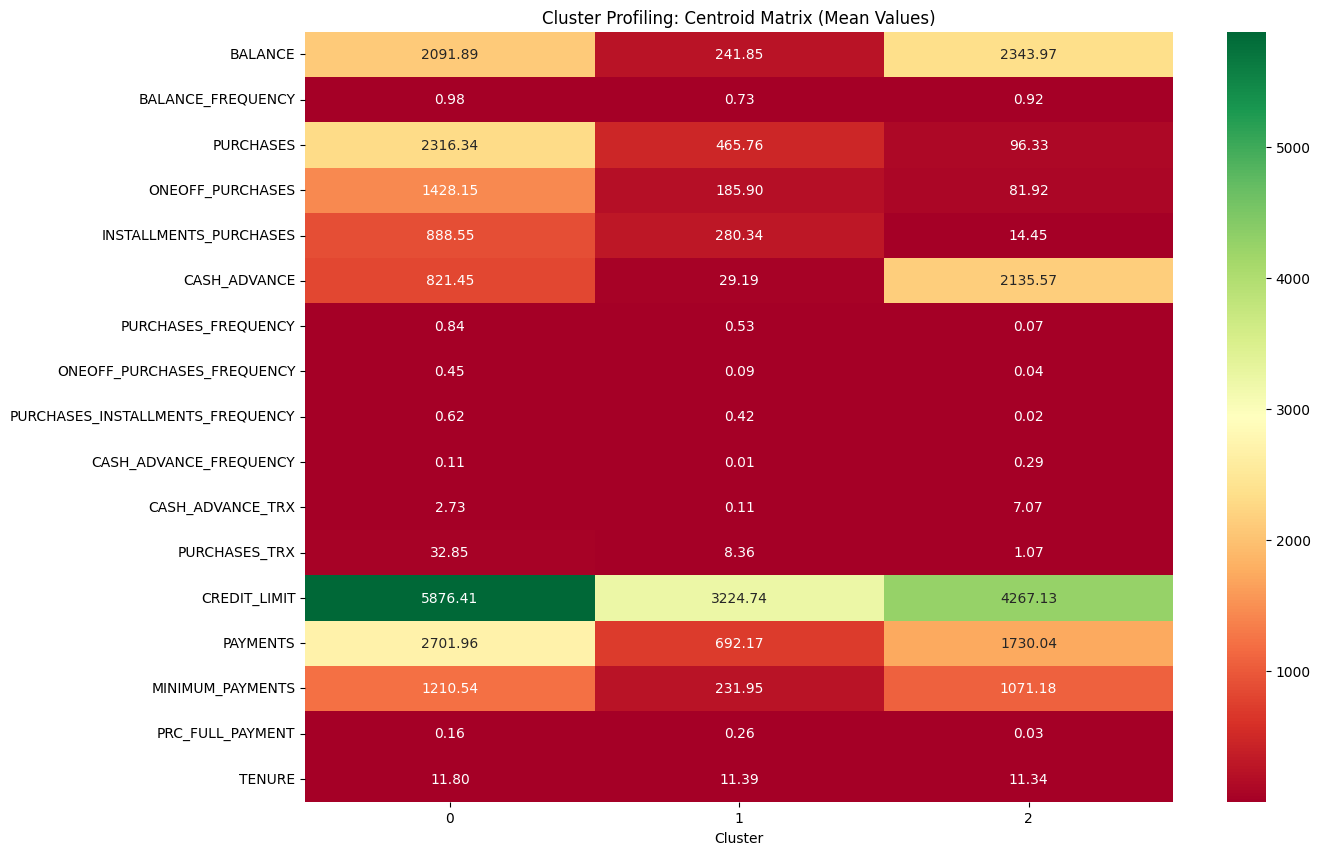

In [3]:
cluster_centroids = df_raw.groupby('Cluster').mean()

cluster_centroids_T = cluster_centroids.T

display(cluster_centroids_T)

plt.figure(figsize=(14, 10))
sns.heatmap(cluster_centroids_T, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Cluster Profiling: Centroid Matrix (Mean Values)')
plt.show()

## 3. Visualizing High-Dimensional Differences
To understand the "shape" of our clusters, we use **Radar Charts** (Spider Plots). Mathematically, this is a way to plot a multivariate vector $\vec{\mu}_j$ on a radial axis. 

Since the features have different scales (e.g., Balance vs. Tenure), we apply a **Min-Max Scaling** strictly for visualization purposes to bring all dimensions into the range $[0, 1]$.

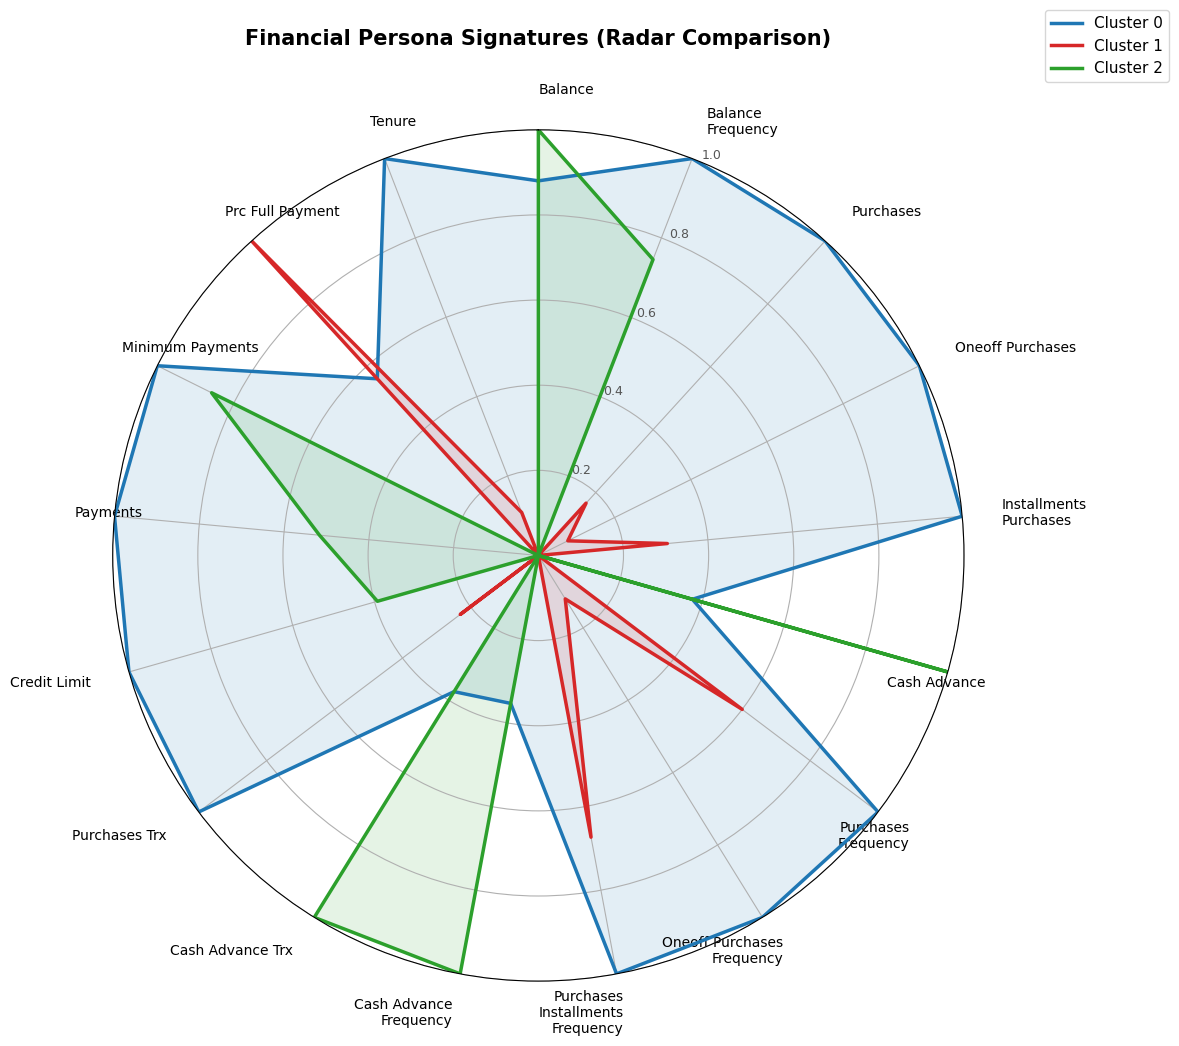

In [4]:
scaler = MinMaxScaler()
scaled_centroids = pd.DataFrame(
    scaler.fit_transform(cluster_centroids),
    index=cluster_centroids.index,
    columns=cluster_centroids.columns
)

def plot_radar_chart(df):
    import textwrap

    raw_labels = [col.replace('_', ' ').title() for col in df.columns]
    labels = [textwrap.fill(label, width=16) for label in raw_labels]
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

    colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']

    for i, cluster_id in enumerate(df.index):
        values = df.iloc[i].tolist()
        values += values[:1]
        color = colors[i % len(colors)]
        ax.plot(angles, values, color=color, linewidth=2.5, label=f'Cluster {cluster_id}')
        ax.fill(angles, values, color=color, alpha=0.12)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10)

    for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
        angle_deg = np.degrees(angle)
        if 90 < angle_deg < 270:
            label.set_horizontalalignment('right')
        else:
            label.set_horizontalalignment('left')
        label.set_fontsize(10)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9, color='#555555')
    ax.tick_params(axis='x', pad=18)

    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.15), fontsize=11, frameon=True)
    plt.title('Financial Persona Signatures (Radar Comparison)', fontsize=15, pad=28, weight='bold')
    plt.tight_layout()
    plt.show()

plot_radar_chart(scaled_centroids)

This radar chart compares cluster centroids after feature-wise Min-Max normalization.
For each feature $f$, values are transformed to the interval $[0,1]$ across clusters:

$$
x_{j,f}^{scaled} = \frac{x_{j,f} - \min_j x_{j,f}}{\max_j x_{j,f} - \min_j x_{j,f}}
$$

As a result, the chart emphasizes relative shape differences between personas rather than absolute monetary magnitude.

### What each visual element means

1. Each spoke corresponds to one financial feature (for example, balance, purchases, tenure).
2. Each polygon corresponds to one cluster.
3. A larger radius on a spoke means stronger relative expression of that feature for that cluster.
4. Overlapping polygons indicate similarity; strong separation indicates differentiating traits.

### Why scaling is necessary

Features are measured in different units and ranges. Without scaling, high-range variables would dominate the geometry and hide meaningful structure in lower-range variables. Min-Max scaling makes all features comparable for visualization.

### Practical interpretation rules

1. Use peaks to identify defining strengths of a cluster.
2. Use troughs to identify suppressed or under-expressed behaviors.
3. Read the full polygon shape as a behavioral signature, not single spokes in isolation.
4. Treat this as exploratory evidence and validate conclusions with lift analysis and ANOVA/$\eta^2$ results.

### Important caveat

A value near $1.0$ does not imply a universally high real-world level; it only means highest among the compared clusters for that specific feature.

## 4. Quantitative Profiling Addendum

To strengthen interpretability, we add three quantitative diagnostics on top of centroid and radar visualizations.

### 4.1 Segment Prevalence
For each cluster $j$, let $N_j$ be its cardinality and $n$ the total sample size. Segment prevalence is

$$p_j = \frac{N_j}{n}.$$

This prevents over-interpreting micro-clusters that may look visually distinct but have limited operational impact.

### 4.2 Relative Lift Against Population Baseline
For feature $f$, with cluster mean $\mu_{j,f}$ and global mean $\mu_f$, define relative lift as

$$L_{j,f} = \frac{\mu_{j,f} - \mu_f}{\mu_f}.$$

Positive lift indicates feature over-expression in cluster $j$, while negative lift indicates under-expression.

### 4.3 Statistical Separation Across Clusters
For each feature $f$, we test
$$H_0: \mu_{1,f} = \mu_{2,f} = \dots = \mu_{k,f}$$
using one-way ANOVA. The resulting $F$-statistic quantifies between-cluster variance relative to within-cluster variance.

As an effect-size proxy, we also compute

$$\eta_f^2 = \frac{SS_{\text{between},f}}{SS_{\text{total},f}},$$

which estimates how much of the variance of feature $f$ is explained by cluster membership.

In [5]:
feature_cols = [col for col in df_raw.columns if col != 'Cluster']

cluster_size_table = (
    df_raw['Cluster']
    .value_counts()
    .sort_index()
    .rename_axis('Cluster')
    .to_frame('Count')
)
cluster_size_table['Proportion'] = cluster_size_table['Count'] / len(df_raw)

print('Segment prevalence table:')
display(cluster_size_table)

global_mean = df_raw[feature_cols].mean()
denominator = global_mean.replace(0, np.nan)
lift_matrix = (cluster_centroids[feature_cols] - global_mean) / denominator

print('Lift matrix (relative deviation vs global mean):')
display(lift_matrix.round(3))

top_driver_rows = []
for cluster_id in lift_matrix.index:
    cluster_lift = lift_matrix.loc[cluster_id].dropna()
    top_positive = cluster_lift.sort_values(ascending=False).head(3)
    top_negative = cluster_lift.sort_values(ascending=True).head(3)

    for feature_name, lift_value in top_positive.items():
        top_driver_rows.append({
            'Cluster': cluster_id,
            'Direction': 'Positive',
            'Feature': feature_name,
            'Lift': lift_value
        })

    for feature_name, lift_value in top_negative.items():
        top_driver_rows.append({
            'Cluster': cluster_id,
            'Direction': 'Negative',
            'Feature': feature_name,
            'Lift': lift_value
        })

top_drivers = pd.DataFrame(top_driver_rows).sort_values(['Cluster', 'Direction', 'Lift'], ascending=[True, True, False])
print('Top positive and negative drivers per cluster:')
display(top_drivers)

Segment prevalence table:


,Count,Proportion
Cluster,,
0,3167,0.353855
1,2939,0.328380
2,2844,0.317765


Lift matrix (relative deviation vs global mean):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,0.337,0.118,1.309,1.411,1.162,-0.161,0.704,1.220,0.694,-0.189,-0.160,1.233,0.308,0.559,0.433,0.052,0.024
1,-0.845,-0.171,-0.536,-0.686,-0.318,-0.970,0.077,-0.549,0.161,-0.936,-0.965,-0.432,-0.282,-0.601,-0.725,0.709,-0.011
2,0.498,0.045,-0.904,-0.862,-0.965,1.182,-0.864,-0.791,-0.939,1.177,1.175,-0.927,-0.051,-0.002,0.268,-0.791,-0.016


Top positive and negative drivers per cluster:


,Cluster,Direction,Feature,Lift
5,0,Negative,CASH_ADVANCE_TRX,-0.159688
4,0,Negative,CASH_ADVANCE,-0.160816
3,0,Negative,CASH_ADVANCE_FREQUENCY,-0.188654
0,0,Positive,ONEOFF_PURCHASES,1.410639
1,0,Positive,PURCHASES,1.308937
2,0,Positive,PURCHASES_TRX,1.232987
11,1,Negative,CASH_ADVANCE_FREQUENCY,-0.935535
10,1,Negative,CASH_ADVANCE_TRX,-0.964810
9,1,Negative,CASH_ADVANCE,-0.970180
6,1,Positive,PRC_FULL_PAYMENT,0.709472


### 4.4 Inference Layer: ANOVA and Effect Size
The next code cell tests whether observed cluster differences are statistically reliable for each feature.

For each variable $f$, ANOVA computes an $F$-ratio between between-cluster and within-cluster variability. We report the corresponding $p$-value to evaluate the null hypothesis of equal means across clusters.

To complement significance testing, we compute $\eta^2$ as an effect-size estimate. This quantifies practical explanatory strength, helping distinguish statistically significant but weak effects from substantively meaningful separation.

In [6]:
anova_rows = []
for feature in feature_cols:
    groups = [
        grp[feature].values
        for _, grp in df_raw.groupby('Cluster')
    ]

    f_stat, p_value = stats.f_oneway(*groups)

    overall_mean = df_raw[feature].mean()
    ss_between = sum(len(g) * (np.mean(g) - overall_mean) ** 2 for g in groups)
    ss_total = ((df_raw[feature] - overall_mean) ** 2).sum()
    eta_sq = ss_between / ss_total if ss_total > 0 else np.nan

    anova_rows.append({
        'Feature': feature,
        'F-statistic': f_stat,
        'p-value': p_value,
        'eta_squared': eta_sq
    })

anova_results = pd.DataFrame(anova_rows).sort_values('p-value')
anova_results['Significant (alpha=0.05)'] = anova_results['p-value'] < 0.05

print('ANOVA feature-separation results (sorted by p-value):')
display(anova_results.head(15))

print('Number of statistically significant features:', int(anova_results['Significant (alpha=0.05)'].sum()))

cluster_size_table.to_csv('cluster_size_table.csv')
lift_matrix.to_csv('cluster_lift_matrix.csv')
anova_results.to_csv('cluster_feature_anova.csv', index=False)
print('Exported: cluster_size_table.csv, cluster_lift_matrix.csv, cluster_feature_anova.csv')

ANOVA feature-separation results (sorted by p-value):


,Feature,F-statistic,p-value,eta_squared,Significant (alpha=0.05)
0,BALANCE,1117.570459,0.000000e+00,0.199885,True
1,BALANCE_FREQUENCY,1174.377988,0.000000e+00,0.207933,True
2,PURCHASES,1201.365648,0.000000e+00,0.211699,True
4,INSTALLMENTS_PURCHASES,894.556050,0.000000e+00,0.166644,True
6,PURCHASES_FREQUENCY,7273.781326,0.000000e+00,0.619188,True
5,CASH_ADVANCE,890.535870,0.000000e+00,0.166020,True
7,ONEOFF_PURCHASES_FREQUENCY,2737.126678,0.000000e+00,0.379596,True
8,PURCHASES_INSTALLMENTS_FREQUENCY,2813.414807,0.000000e+00,0.386091,True
10,CASH_ADVANCE_TRX,921.018606,0.000000e+00,0.170732,True
9,CASH_ADVANCE_FREQUENCY,2279.573165,0.000000e+00,0.337561,True


Number of statistically significant features: 17
Exported: cluster_size_table.csv, cluster_lift_matrix.csv, cluster_feature_anova.csv


## 5. Wrap-Up and Transition
Notebook 4 converted latent-space segments into interpretable financial personas by estimating cluster centroids in the original feature space, then validating separation through prevalence, lift, and ANOVA/$\eta^2$ diagnostics.

Operationally, this yields a mapping
$$c_i \mapsto \vec{\mu}_{c_i}$$
that links each customer label to an economically meaningful behavioral profile.

In Notebook 5, these validated personas are translated into targeted business strategy, decision rules, and implementation-focused recommendations.